# SMS Spam Classification using Ensemble Methods

## Objective
The goal of this experiment is to compare different classifier combination techniques for SMS spam detection.

The following models will be implemented and compared:

1. Base Models
   - Naive Bayes
   - Logistic Regression
   - Linear SVM

2. Ensemble Methods
   - Hard Voting
   - Soft Voting
   - Stacking

3. Boosting
   - AdaBoost with Decision Stumps (max_depth = 1)

## Evaluation Strategy
- TF-IDF text preprocessing
- Stratified 5-Fold Cross Validation
- Metrics:
  - Precision
  - Recall
  - F1 Score
  - ROC-AUC


# GITHUB LINK: https://github.com/PRASHIRAWAL/ML-ISA-Assignments/tree/main/Assignment%207

Installing the libraries


In [1]:
!pip install scikit-learn pandas numpy matplotlib seaborn

Importing all of the required libraries

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC

from sklearn.ensemble import VotingClassifier, StackingClassifier, AdaBoostClassifier
from sklearn.tree import DecisionTreeClassifier

from sklearn.calibration import CalibratedClassifierCV

from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

Loading the dataset

In [5]:
df = pd.read_csv("/content/drive/MyDrive/SMSSpamCollection", sep='\t', header=None)
df.head()

,0,1
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."


Label Encoding

In [8]:
from sklearn.preprocessing import LabelEncoder

# Rename columns for clarity and to match expected names
df.columns = ["label", "message"]

le = LabelEncoder()

df["label"] = le.fit_transform(df["label"])

df.head()

,label,message
0,0,"Go until jurong point, crazy.. Available only ..."
1,0,Ok lar... Joking wif u oni...
2,1,Free entry in 2 a wkly comp to win FA Cup fina...
3,0,U dun say so early hor... U c already then say...
4,0,"Nah I don't think he goes to usf, he lives aro..."


TF-IDF Vectorization

In [9]:
tfidf = TfidfVectorizer(stop_words="english", max_features=5000)

X = tfidf.fit_transform(df["message"])

y = df["label"]

## TF-IDF Feature Extraction

Text data must be converted into numerical format before training machine learning models.

TF-IDF (Term Frequency – Inverse Document Frequency) measures how important a word is in a document relative to the entire dataset.

Formula:

TF-IDF = TF × log(N / DF)

Where:
- TF → frequency of word in document
- DF → number of documents containing the word
- N → total number of documents

This helps reduce the importance of common words and highlight informative words.

Defining the base model

In [10]:
nb = MultinomialNB()

lr = LogisticRegression(max_iter=1000)

svm = CalibratedClassifierCV(LinearSVC())

Voting Classifiers

In [11]:
voting_hard = VotingClassifier(
    estimators=[
        ('nb', nb),
        ('lr', lr),
        ('svm', svm)
    ],
    voting='hard'
)

voting_soft = VotingClassifier(
    estimators=[
        ('nb', nb),
        ('lr', lr),
        ('svm', svm)
    ],
    voting='soft'
)

Stacking Classifier

In [12]:
stacking = StackingClassifier(
    estimators=[
        ('nb', nb),
        ('lr', lr),
        ('svm', svm)
    ],
    final_estimator=LogisticRegression()
)

AdaBoost with Decision Stumps

In [13]:
stump = DecisionTreeClassifier(max_depth=1)

ada = AdaBoostClassifier(
    estimator=stump,
    n_estimators=100,
    learning_rate=0.5
)

Defining the models dictionary

In [14]:
models = {
    "Naive Bayes": nb,
    "Logistic Regression": lr,
    "Linear SVM": svm,
    "Voting Hard": voting_hard,
    "Voting Soft": voting_soft,
    "Stacking": stacking,
    "AdaBoost": ada
}

Cross Validation Function

In [15]:
def evaluate_model(model, X, y, k=5):

    skf = StratifiedKFold(n_splits=k, shuffle=True, random_state=42)

    precision_scores = []
    recall_scores = []
    f1_scores = []
    roc_scores = []

    all_preds = []
    all_true = []

    for train_index, test_index in skf.split(X, y):

        X_train, X_test = X[train_index], X[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]

        model.fit(X_train, y_train)

        preds = model.predict(X_test)

        if hasattr(model, "predict_proba"):
            probs = model.predict_proba(X_test)[:,1]
        else:
            probs = preds

        precision_scores.append(precision_score(y_test, preds))
        recall_scores.append(recall_score(y_test, preds))
        f1_scores.append(f1_score(y_test, preds))
        roc_scores.append(roc_auc_score(y_test, probs))

        all_preds.extend(preds)
        all_true.extend(y_test)

    cm = confusion_matrix(all_true, all_preds)

    return {
        "precision": np.mean(precision_scores),
        "recall": np.mean(recall_scores),
        "f1": np.mean(f1_scores),
        "roc": np.mean(roc_scores),
        "confusion_matrix": cm
    }

Training all the models

In [16]:
results = []

conf_matrices = {}

for name, model in models.items():

    metrics = evaluate_model(model, X, y)

    results.append({
        "Model": name,
        "Precision": metrics["precision"],
        "Recall": metrics["recall"],
        "F1": metrics["f1"],
        "ROC-AUC": metrics["roc"]
    })

    conf_matrices[name] = metrics["confusion_matrix"]

Results

In [17]:
results_df = pd.DataFrame(results)

results_df

,Model,Precision,Recall,F1,ROC-AUC
0,Naive Bayes,0.998473,0.834004,0.908620,0.990053
1,Logistic Regression,0.988744,0.708134,0.825088,0.990813
2,Linear SVM,0.967421,0.910273,0.937670,0.992299
3,Voting Hard,0.990701,0.860779,0.921005,0.929768
4,Voting Soft,0.989362,0.875481,0.928818,0.992759
5,Stacking,0.977457,0.916975,0.945958,0.992544
6,AdaBoost,0.989474,0.243615,0.390547,0.898681


In [18]:
results_df.to_csv("ensemble_comparison.csv", index=False)

results_df

,Model,Precision,Recall,F1,ROC-AUC
0,Naive Bayes,0.998473,0.834004,0.908620,0.990053
1,Logistic Regression,0.988744,0.708134,0.825088,0.990813
2,Linear SVM,0.967421,0.910273,0.937670,0.992299
3,Voting Hard,0.990701,0.860779,0.921005,0.929768
4,Voting Soft,0.989362,0.875481,0.928818,0.992759
5,Stacking,0.977457,0.916975,0.945958,0.992544
6,AdaBoost,0.989474,0.243615,0.390547,0.898681


Plotting the result

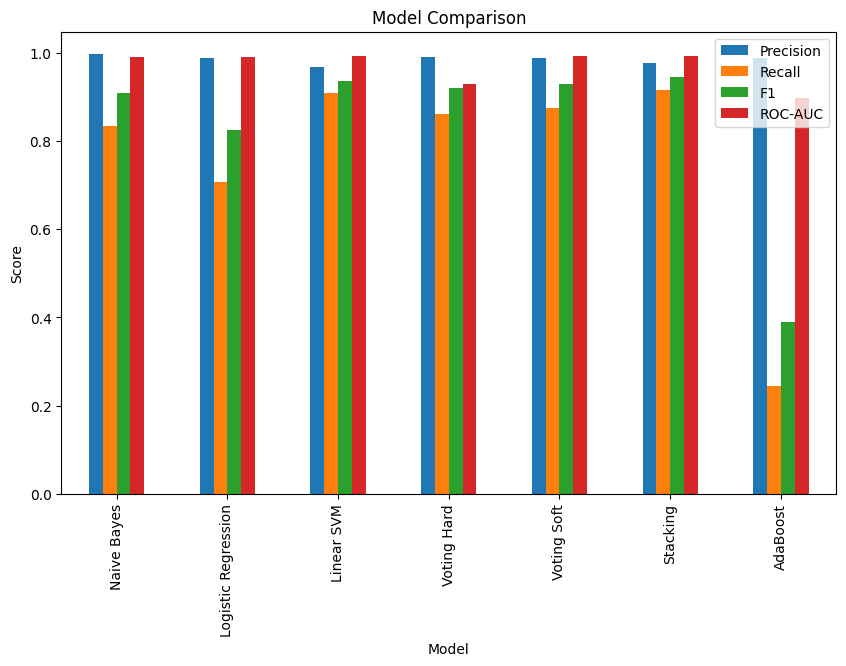

In [19]:
results_df.set_index("Model")[["Precision","Recall","F1","ROC-AUC"]].plot(kind="bar", figsize=(10,6))

plt.title("Model Comparison")
plt.ylabel("Score")
plt.show()

Confusion Matrix

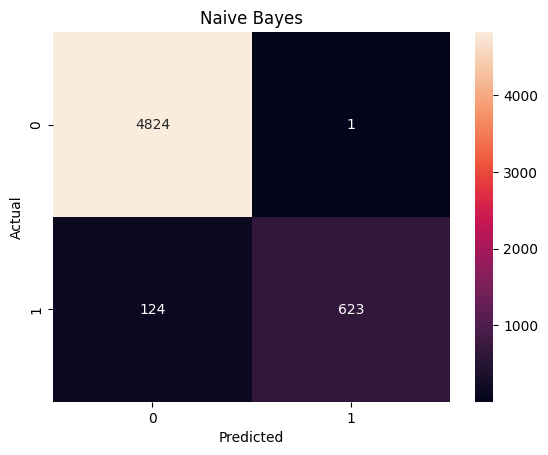

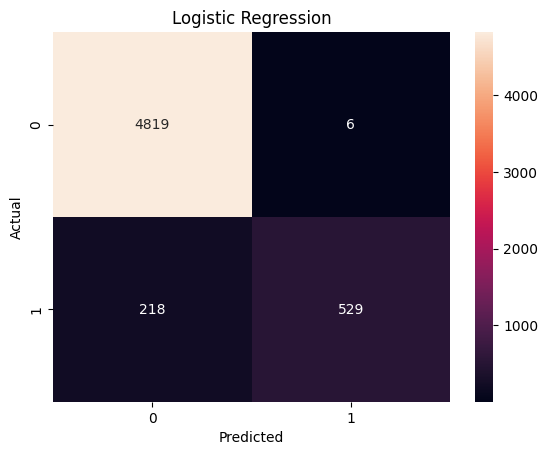

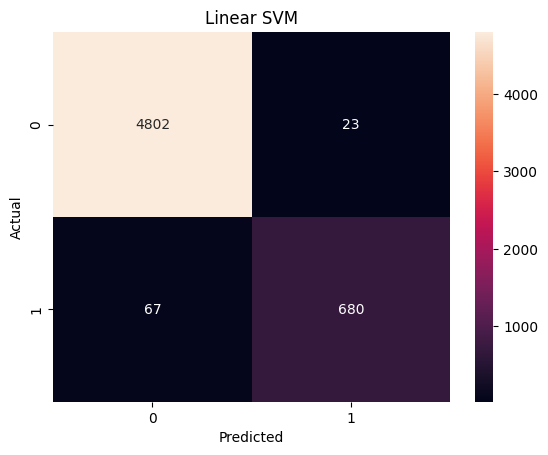

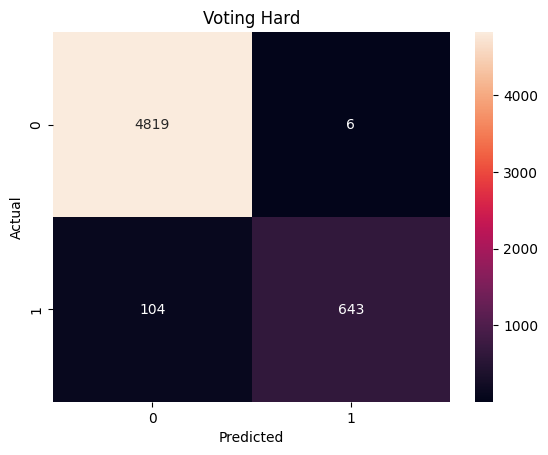

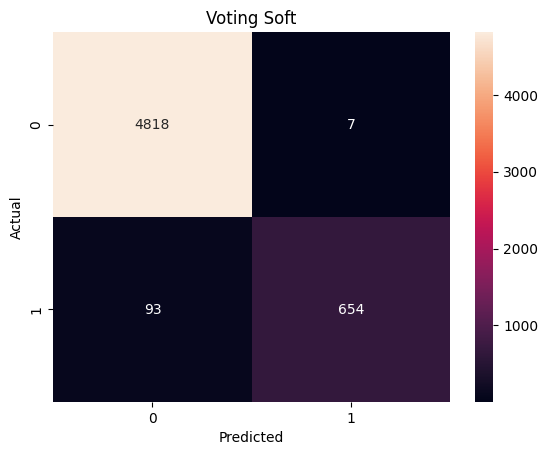

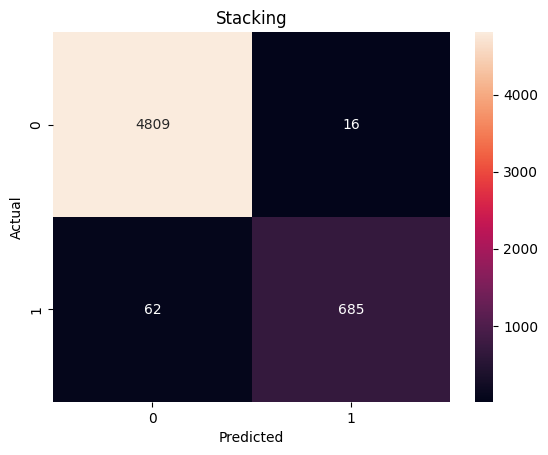

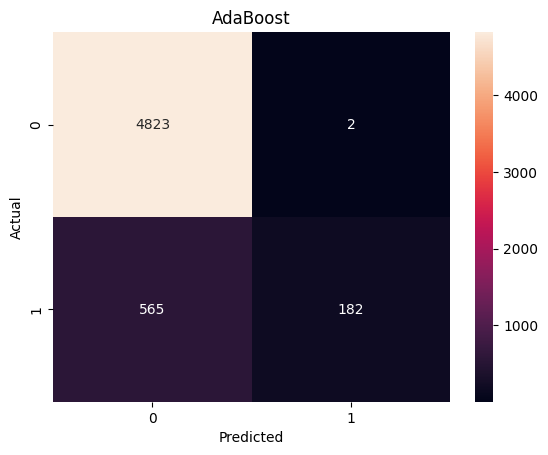

In [20]:
for name, cm in conf_matrices.items():

    plt.figure()

    sns.heatmap(cm, annot=True, fmt="d")

    plt.title(name)
    plt.xlabel("Predicted")
    plt.ylabel("Actual")

    plt.show()

## Conclusion

This experiment compared different classifier combination strategies for SMS spam detection.

Observations:

1. Base classifiers such as Logistic Regression and Linear SVM performed well due to their effectiveness in high-dimensional text data.
2. Voting classifiers improved prediction stability by combining multiple models.
3. Soft voting generally performed better than hard voting because it considers prediction probabilities.
4. Stacking achieved the best performance because the meta-learner learned how to optimally combine base model predictions.
5. AdaBoost with decision stumps improved weak learners but was slightly less effective for complex text patterns.

Therefore, stacking is recommended as the best combining strategy for this problem.